# 通过cal_Silhouette_KNN.py获得结果后作图（fig3：对比学习优势）

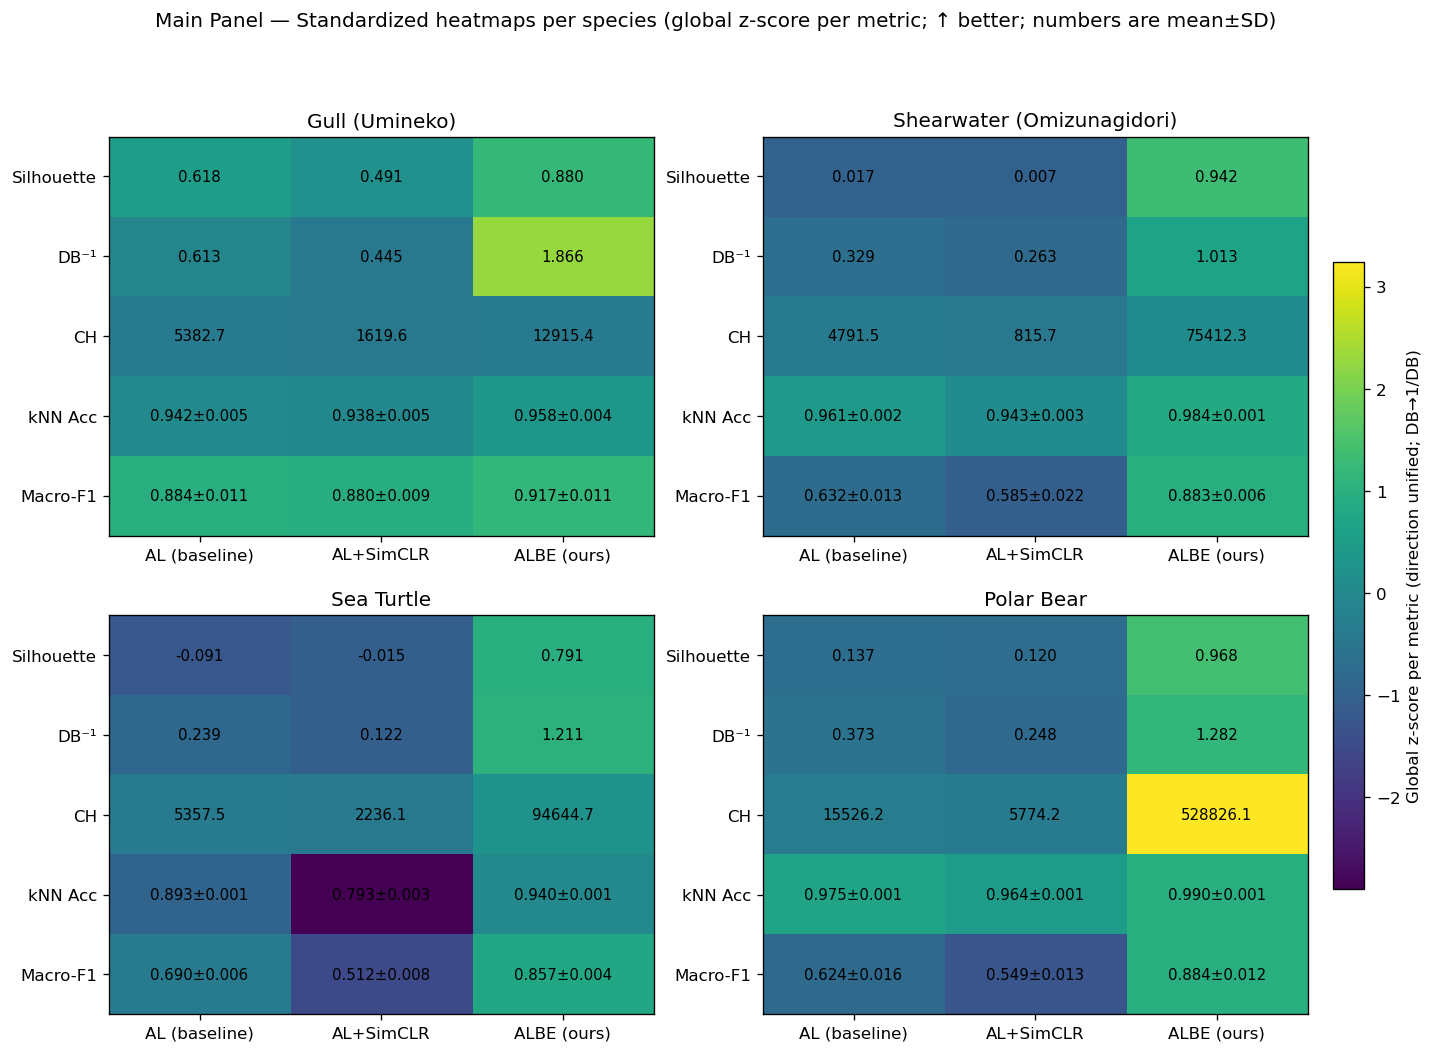

In [6]:
# -*- coding: utf-8 -*-
"""
Figure 3 - Panel C
2x2 heatmaps (four species) with a shared colorbar.
- Direction unified: DB -> 1/DB (so all metrics are "larger is better")
- Normalization: global z-score per metric across ALL species & methods
- Cell annotations show original values (kNN/F1 show mean±SD; DB row shows 1/DB)

Dependencies: numpy, matplotlib
"""

import re
import numpy as np
import matplotlib.pyplot as plt
from textwrap import dedent

# ---------- 1) Paste your raw results text here ----------
raw_text = dedent("""
umineko： iter 20
albe
[Iter 0] Silhouette=0.880 | DB=0.536 | CH=12915.4 | kNN k=5 folds=5 Acc=0.958±0.004 | Macro-F1=0.917±0.011 | labeled=1180 unlabeled=4763
random
[Iter 0] Silhouette=0.618 | DB=1.632 | CH=5382.7 | kNN k=5 folds=5 Acc=0.942±0.005 | Macro-F1=0.884±0.011 | labeled=1180 unlabeled=4763
simclr
[Iter 0] Silhouette=0.491 | DB=2.246 | CH=1619.6 | kNN k=5 folds=5 Acc=0.938±0.005 | Macro-F1=0.880±0.009 | labeled=1180 unlabeled=4763

omizunagidori
albe
[Iter 0] Silhouette=0.942 | DB=0.987 | CH=75412.3 | kNN k=5 folds=5 Acc=0.984±0.001 | Macro-F1=0.883±0.006 | labeled=3480 unlabeled=14014
random
[Iter 0] Silhouette=0.017 | DB=3.043 | CH=4791.5 | kNN k=5 folds=5 Acc=0.961±0.002 | Macro-F1=0.632±0.013 | labeled=3480 unlabeled=14014
simclr
[Iter 0] Silhouette=0.007 | DB=3.801 | CH=815.7 | kNN k=5 folds=5 Acc=0.943±0.003 | Macro-F1=0.585±0.022 | labeled=3480 unlabeled=14014

sea turtle
albe
[Iter 0] Silhouette=0.791 | DB=0.826 | CH=94644.7 | kNN k=5 folds=5 Acc=0.940±0.001 | Macro-F1=0.857±0.004 | labeled=20640 unlabeled=82584
random
[Iter 0] Silhouette=-0.091 | DB=4.178 | CH=5357.5 | kNN k=5 folds=5 Acc=0.893±0.001 | Macro-F1=0.690±0.006 | labeled=20640 unlabeled=82584
simclr
[Iter 0] Silhouette=-0.015 | DB=8.176 | CH=2236.1 | kNN k=5 folds=5 Acc=0.793±0.003 | Macro-F1=0.512±0.008 | labeled=20640 unlabeled=82584

polar bear
albe
[Iter 0] Silhouette=0.968 | DB=0.780 | CH=528826.1 | kNN k=5 folds=5 Acc=0.990±0.001 | Macro-F1=0.884±0.012 | labeled=36140 unlabeled=144592
random
[Iter 0] Silhouette=0.137 | DB=2.684 | CH=15526.2 | kNN k=5 folds=5 Acc=0.975±0.001 | Macro-F1=0.624±0.016 | labeled=36140 unlabeled=144592
simclr
[Iter 0] Silhouette=0.120 | DB=4.030 | CH=5774.2 | kNN k=5 folds=5 Acc=0.964±0.001 | Macro-F1=0.549±0.013 | labeled=36140 unlabeled=144592
""")

# ---------- 2) Parse ----------
species_order = ["umineko", "omizunagidori", "sea turtle", "polar bear"]
method_order  = ["random", "simclr", "albe"]  # columns: AL (baseline), AL+SimCLR, ALBE (ours)

pattern_metrics = re.compile(
    r"Silhouette=([-\d\.]+)\s*\|\s*DB=([-\d\.]+)\s*\|\s*CH=([-\d\.]+)\s*\|\s*kNN k=5 folds=5 Acc=([\d\.]+)±([\d\.]+)\s*\|\s*Macro-F1=([\d\.]+)±([\d\.]+)"
)

data = {}
cur_species = None
cur_method = None

for line in raw_text.splitlines():
    s = line.strip()
    if not s:
        continue
    low = s.lower()

    # species?
    matched_sp = None
    for sp in species_order:
        if sp in low:
            matched_sp = sp
            break
    if matched_sp is not None:
        cur_species = matched_sp
        data.setdefault(cur_species, {})
        cur_method = None
        continue

    # method?
    if s.lower() in {"albe", "random", "simclr"}:
        cur_method = s.lower()
        continue

    # metrics line?
    m = pattern_metrics.search(s)
    if m and cur_species and cur_method:
        vals = list(map(float, m.groups()))
        data[cur_species][cur_method] = {
            "Silhouette": vals[0],
            "DB": vals[1],
            "CH": vals[2],
            "kNN_mean": vals[3],
            "kNN_sd": vals[4],
            "F1_mean": vals[5],
            "F1_sd": vals[6],
        }

# ---------- 3) Build matrices with direction unified ----------
row_names = ["Silhouette", "DB⁻¹", "CH", "kNN Acc", "Macro-F1"]
col_names = ["AL (baseline)", "AL+SimCLR", "ALBE (ours)"]

def metric_matrix(metric_key):
    M = np.zeros((len(species_order), len(method_order)), dtype=float)
    disp = np.empty_like(M, dtype=object)  # strings to annotate
    for i, sp in enumerate(species_order):
        for j, md in enumerate(method_order):
            rec = data[sp][md]
            if metric_key == "Silhouette":
                M[i, j] = rec["Silhouette"]
                disp[i, j] = f"{rec['Silhouette']:.3f}"
            elif metric_key == "DB⁻¹":
                inv = 1.0 / rec["DB"]
                M[i, j] = inv
                disp[i, j] = f"{inv:.3f}"
            elif metric_key == "CH":
                M[i, j] = rec["CH"]
                disp[i, j] = f"{rec['CH']:.1f}"
            elif metric_key == "kNN Acc":
                M[i, j] = rec["kNN_mean"]
                disp[i, j] = f"{rec['kNN_mean']:.3f}±{rec['kNN_sd']:.3f}"
            elif metric_key == "Macro-F1":
                M[i, j] = rec["F1_mean"]
                disp[i, j] = f"{rec['F1_mean']:.3f}±{rec['F1_sd']:.3f}"
    return M, disp

# For each metric, compute z-score over ALL species & methods (global normalize)
Z_by_metric = {}
Disp_by_metric = {}
for rn in row_names:
    M, D = metric_matrix(rn)
    mu, sd = M.mean(), M.std() + 1e-12
    Z_by_metric[rn] = (M - mu) / sd
    Disp_by_metric[rn] = D

# global color range (shared colorbar)
all_z = np.concatenate([Z_by_metric[rn].ravel() for rn in row_names])
vmin, vmax = all_z.min(), all_z.max()

title_map = {
    "umineko": "Gull (Umineko)",
    "omizunagidori": "Shearwater (Omizunagidori)",
    "sea turtle": "Sea Turtle",
    "polar bear": "Polar Bear",
}

# ---------- 4) Plot: 2x2 subplots with shared colorbar ----------
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5), dpi=120)
axes = axes.ravel()

for ax, sp in zip(axes, species_order):
    # stack rows (5 x 3)
    Z_rows = [Z_by_metric[rn][species_order.index(sp):species_order.index(sp)+1, :]
              for rn in row_names]
    Z = np.vstack(Z_rows)
    im = ax.imshow(Z, aspect="auto", vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(col_names)))
    ax.set_xticklabels(col_names, rotation=0)
    ax.set_yticks(np.arange(len(row_names)))
    ax.set_yticklabels(row_names)

    ax.set_title(title_map.get(sp, sp.title()), pad=6)

    # annotate: use original values (or 1/DB for DB row)
    for r, rn in enumerate(row_names):
        for c in range(len(col_names)):
            txt = Disp_by_metric[rn][species_order.index(sp), c]
            ax.text(c, r, txt, ha="center", va="center", fontsize=9)

# shared colorbar on the right
cbar = fig.colorbar(im, ax=axes.tolist(), fraction=0.025, pad=0.02)
cbar.set_label("Global z-score per metric (direction unified; DB→1/DB)")

fig.suptitle("Main Panel — Standardized heatmaps per species (global z-score per metric; ↑ better; numbers are mean±SD)", y=0.99)

# plt.tight_layout(rect=[0.0, 0.0, 0.95, 0.96])
plt.show()


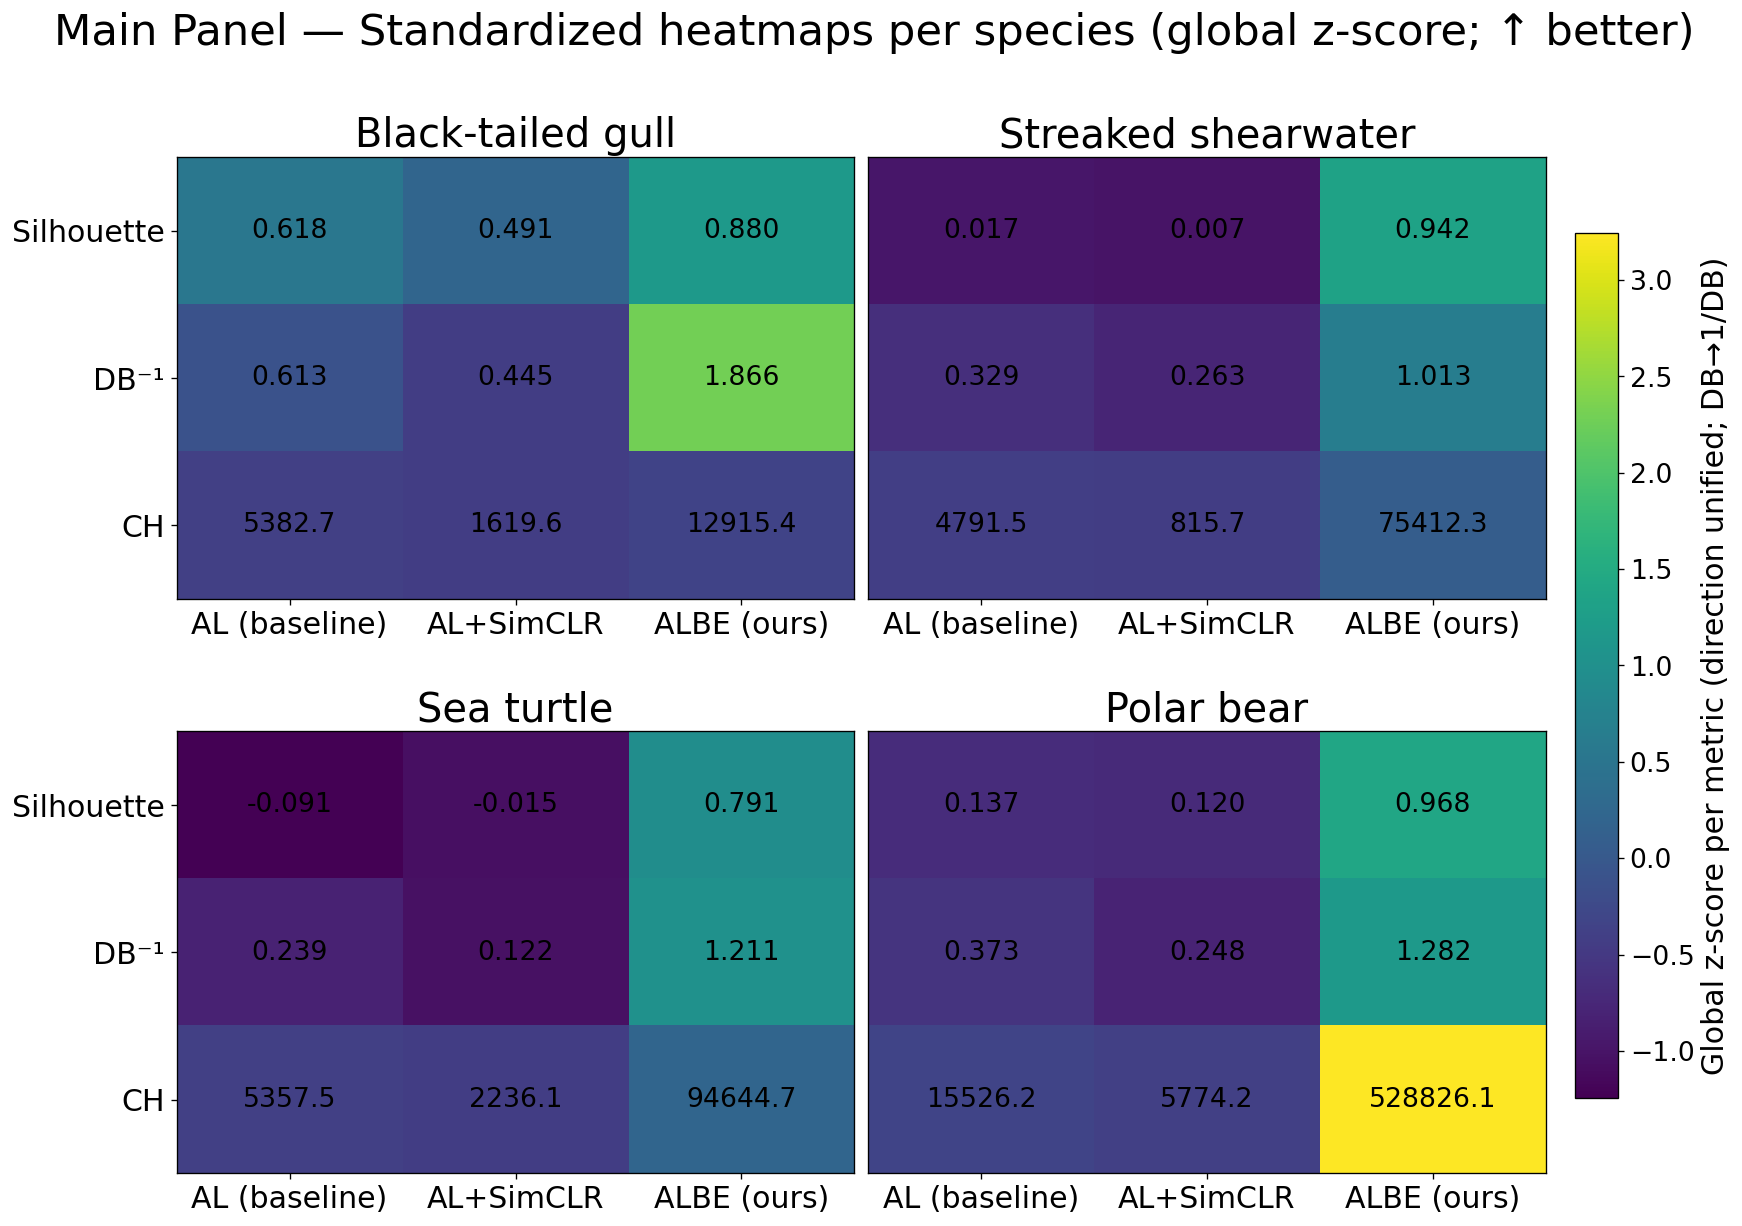

In [7]:
# -*- coding: utf-8 -*-
# Figure 3 - Panel C (Silhouette / DB^-1 / CH), 2x2 heatmaps + shared colorbar
# - Hide y-axis for streaked shearwater & polar bear
# - Reduce inter-column spacing; compress heatmap height
# - DB -> 1/DB; global z-score per metric; annotate with original numbers

import re
import numpy as np
import matplotlib.pyplot as plt
from textwrap import dedent

# ---------- Raw text ----------
raw_text = dedent("""
umineko： iter 20
albe
[Iter 0] Silhouette=0.880 | DB=0.536 | CH=12915.4 | kNN k=5 folds=5 Acc=0.958±0.004 | Macro-F1=0.917±0.011 | labeled=1180 unlabeled=4763
random
[Iter 0] Silhouette=0.618 | DB=1.632 | CH=5382.7 | kNN k=5 folds=5 Acc=0.942±0.005 | Macro-F1=0.884±0.011 | labeled=1180 unlabeled=4763
simclr
[Iter 0] Silhouette=0.491 | DB=2.246 | CH=1619.6 | kNN k=5 folds=5 Acc=0.938±0.005 | Macro-F1=0.880±0.009 | labeled=1180 unlabeled=4763

omizunagidori
albe
[Iter 0] Silhouette=0.942 | DB=0.987 | CH=75412.3 | kNN k=5 folds=5 Acc=0.984±0.001 | Macro-F1=0.883±0.006 | labeled=3480 unlabeled=14014
random
[Iter 0] Silhouette=0.017 | DB=3.043 | CH=4791.5 | kNN k=5 folds=5 Acc=0.961±0.002 | Macro-F1=0.632±0.013 | labeled=3480 unlabeled=14014
simclr
[Iter 0] Silhouette=0.007 | DB=3.801 | CH=815.7 | kNN k=5 folds=5 Acc=0.943±0.003 | Macro-F1=0.585±0.022 | labeled=3480 unlabeled=14014

sea turtle
albe
[Iter 0] Silhouette=0.791 | DB=0.826 | CH=94644.7 | kNN k=5 folds=5 Acc=0.940±0.001 | Macro-F1=0.857±0.004 | labeled=20640 unlabeled=82584
random
[Iter 0] Silhouette=-0.091 | DB=4.178 | CH=5357.5 | kNN k=5 folds=5 Acc=0.893±0.001 | Macro-F1=0.690±0.006 | labeled=20640 unlabeled=82584
simclr
[Iter 0] Silhouette=-0.015 | DB=8.176 | CH=2236.1 | kNN k=5 folds=5 Acc=0.793±0.003 | Macro-F1=0.512±0.008 | labeled=20640 unlabeled=82584

polar bear
albe
[Iter 0] Silhouette=0.968 | DB=0.780 | CH=528826.1 | kNN k=5 folds=5 Acc=0.990±0.001 | Macro-F1=0.884±0.012 | labeled=36140 unlabeled=144592
random
[Iter 0] Silhouette=0.137 | DB=2.684 | CH=15526.2 | kNN k=5 folds=5 Acc=0.975±0.001 | Macro-F1=0.624±0.016 | labeled=36140 unlabeled=144592
simclr
[Iter 0] Silhouette=0.120 | DB=4.030 | CH=5774.2 | kNN k=5 folds=5 Acc=0.964±0.001 | Macro-F1=0.549±0.013 | labeled=36140 unlabeled=144592
""")

# ---------- Parse ----------
species_order = ["umineko", "omizunagidori", "sea turtle", "polar bear"]
method_order  = ["random", "simclr", "albe"]  # columns

pattern = re.compile(
    r"Silhouette=([-\d\.]+)\s*\|\s*DB=([-\d\.]+)\s*\|\s*CH=([-\d\.]+)\s*\|\s*kNN k=5 folds=5 Acc=([\d\.]+)±([\d\.]+)\s*\|\s*Macro-F1=([\d\.]+)±([\d\.]+)"
)

data, cur_sp, cur_md = {}, None, None
for line in raw_text.splitlines():
    s = line.strip()
    if not s: 
        continue
    low = s.lower()

    sp_hit = None
    for sp in species_order:
        if sp in low:
            sp_hit = sp
            break
    if sp_hit is not None:
        cur_sp = sp_hit
        data.setdefault(cur_sp, {})
        cur_md = None
        continue

    if s.lower() in {"albe", "random", "simclr"}:
        cur_md = s.lower()
        continue

    m = pattern.search(s)
    if m and cur_sp and cur_md:
        a, b, c, *_ = map(float, m.groups())
        data[cur_sp][cur_md] = {"Silhouette": a, "DB": b, "CH": c}

# ---------- Build matrices (DB -> 1/DB; global z-score) ----------
rows = ["Silhouette", "DB⁻¹", "CH"]
cols = ["AL (baseline)", "AL+SimCLR", "ALBE (ours)"]

def to_matrix(row_key):
    M = np.zeros((len(species_order), len(method_order)))
    disp = np.empty_like(M, dtype=object)
    for i, sp in enumerate(species_order):
        for j, md in enumerate(method_order):
            rec = data[sp][md]
            if row_key == "Silhouette":
                val = rec["Silhouette"]; M[i, j] = val; disp[i, j] = f"{val:.3f}"
            elif row_key == "DB⁻¹":
                val = 1.0 / rec["DB"];   M[i, j] = val; disp[i, j] = f"{val:.3f}"
            elif row_key == "CH":
                val = rec["CH"];         M[i, j] = val; disp[i, j] = f"{val:.1f}"
    return M, disp

Z_by_row, Disp_by_row = {}, {}
for r in rows:
    M, D = to_matrix(r)
    mu, sd = M.mean(), M.std() + 1e-12
    Z_by_row[r] = (M - mu) / sd
    Disp_by_row[r] = D

all_z = np.concatenate([Z_by_row[r].ravel() for r in rows])
vmin, vmax = all_z.min(), all_z.max()

# ---------- Labels ----------
title_map = {
    "umineko":       "Black-tailed gull",   # updated
    "omizunagidori": "Streaked shearwater",  # updated
    "sea turtle":    "Sea turtle",
    "polar bear":    "Polar bear",
}

# ---------- Big fonts ----------
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "figure.titlesize": 26,
})

# ---------- Plot (2x2) ----------
# Compress height via smaller figure height; reduce inter-column spacing via wspace
fig, axes = plt.subplots(
    2, 2, figsize=(15.5, 11.0), dpi=120,
    gridspec_kw={"wspace": 0.02, "hspace": 0.30}  # <- shrink column gap & row gap
)
axes = axes.ravel()

for ax, sp in zip(axes, species_order):
    Z = np.vstack([Z_by_row[r][species_order.index(sp):species_order.index(sp)+1, :] for r in rows])
    im = ax.imshow(Z, aspect="auto", vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(cols, rotation=0)
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels(rows)

    # Hide y-axis for streaked shearwater (index 1) & polar bear (index 3)
    if sp in ("omizunagidori", "polar bear"):
        ax.set_yticklabels([])
        ax.set_yticks([])

    ax.set_title(title_map.get(sp, sp.title()), pad=6)

    # Cell annotations
    for r, rn in enumerate(rows):
        for c in range(len(cols)):
            txt = Disp_by_row[rn][species_order.index(sp), c]
            ax.text(c, r, txt, ha="center", va="center", fontsize=16)

# Shared colorbar (right side)
cbar = fig.colorbar(im, ax=axes.tolist(), fraction=0.03, pad=0.02)
cbar.set_label("Global z-score per metric (direction unified; DB→1/DB)", fontsize=18)
cbar.ax.tick_params(labelsize=16)

fig.suptitle("Main Panel — Standardized heatmaps per species (global z-score; ↑ better)", y=0.99)
# plt.tight_layout(rect=[0.0, 0.0, 0.96, 0.97])
plt.show()


# figure 3,contrastive learning的ef pannel，latent space对下游任务的效果

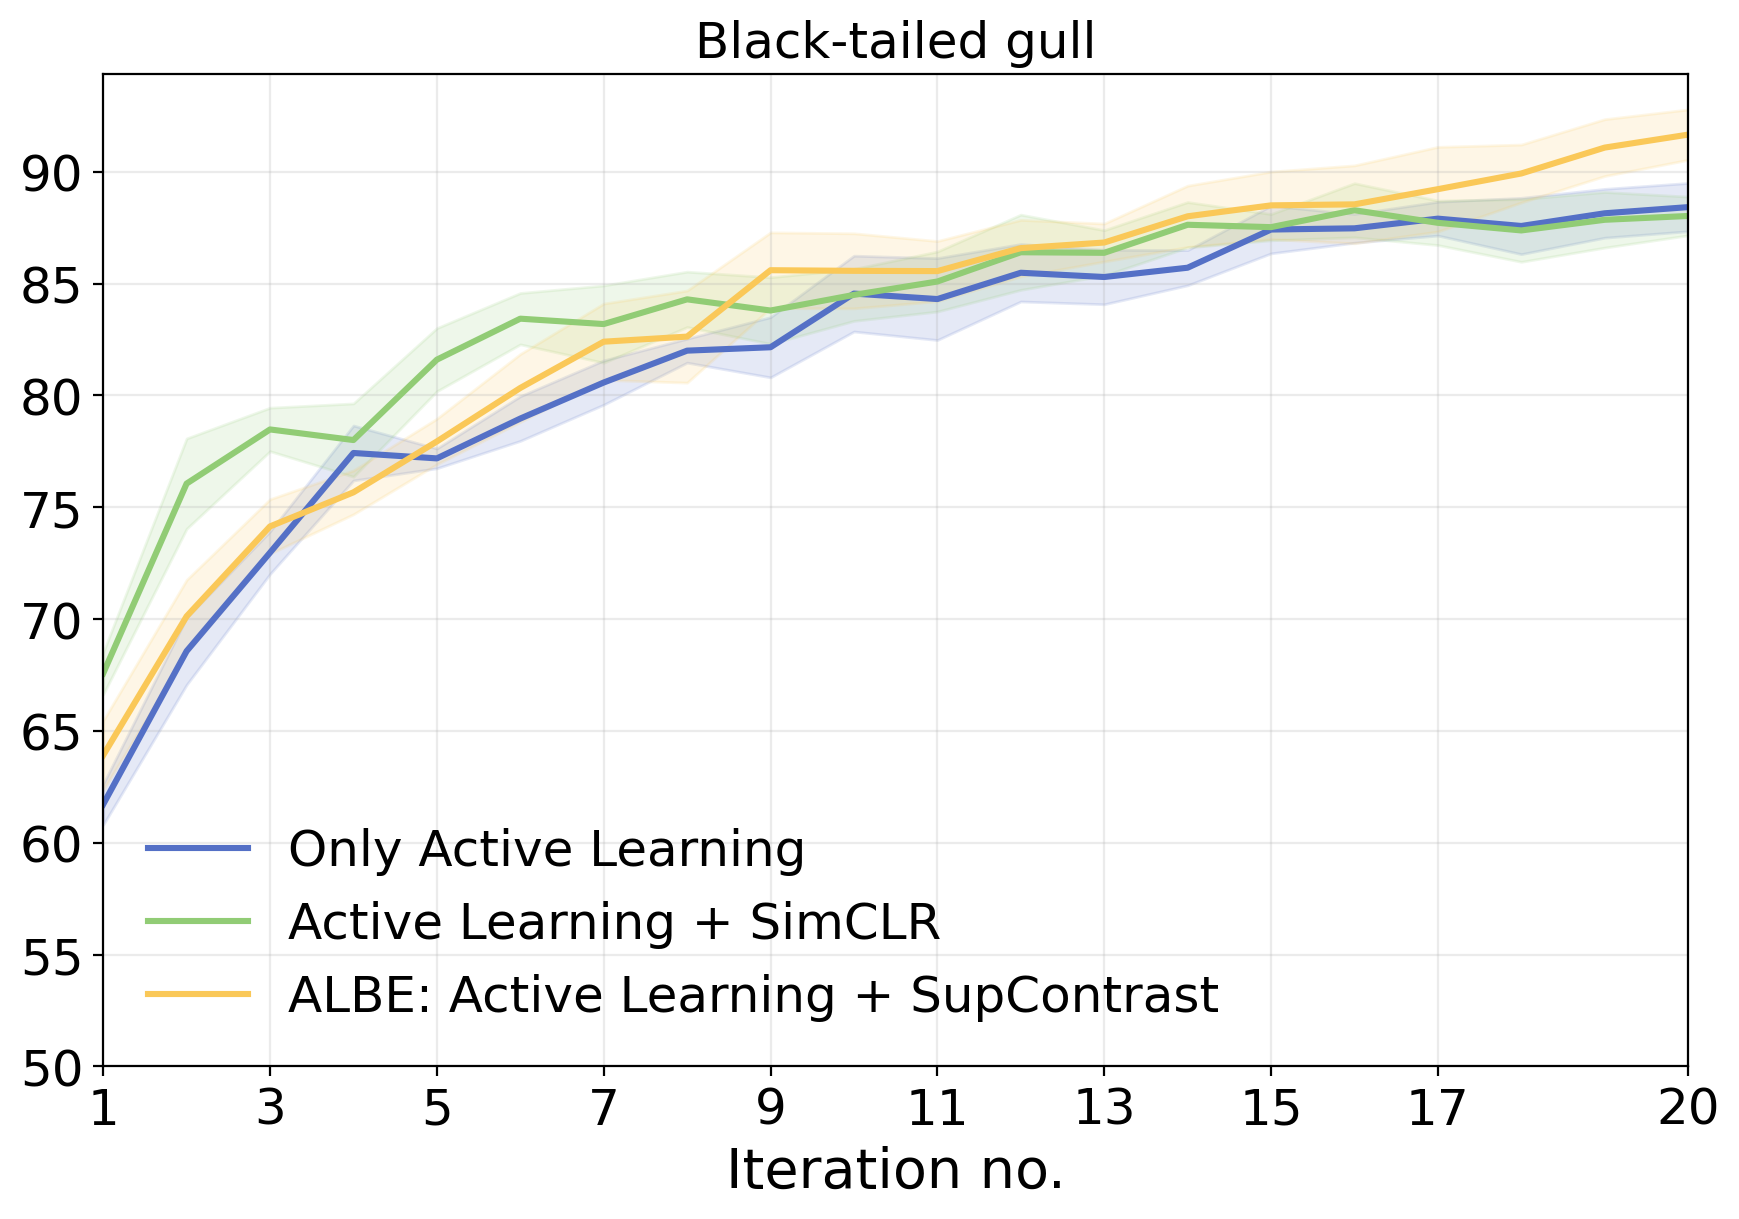

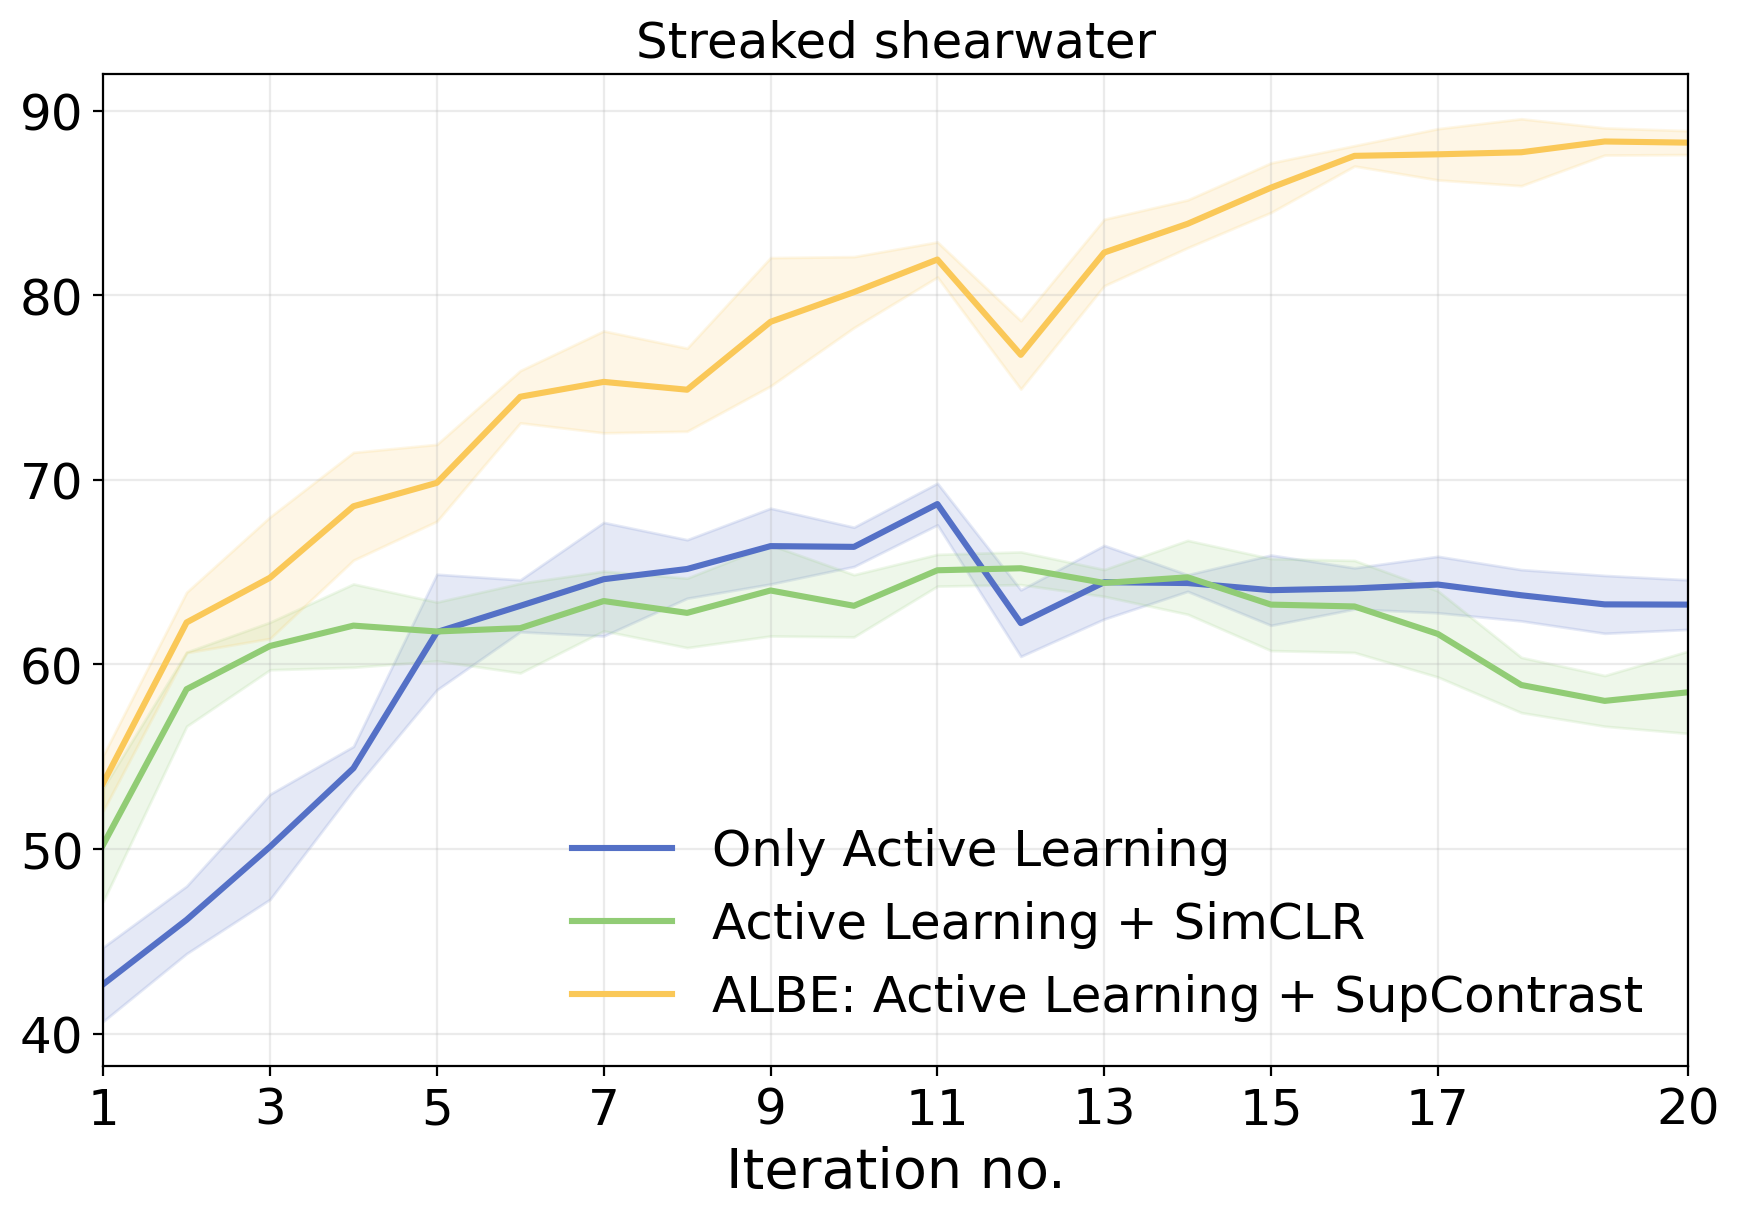

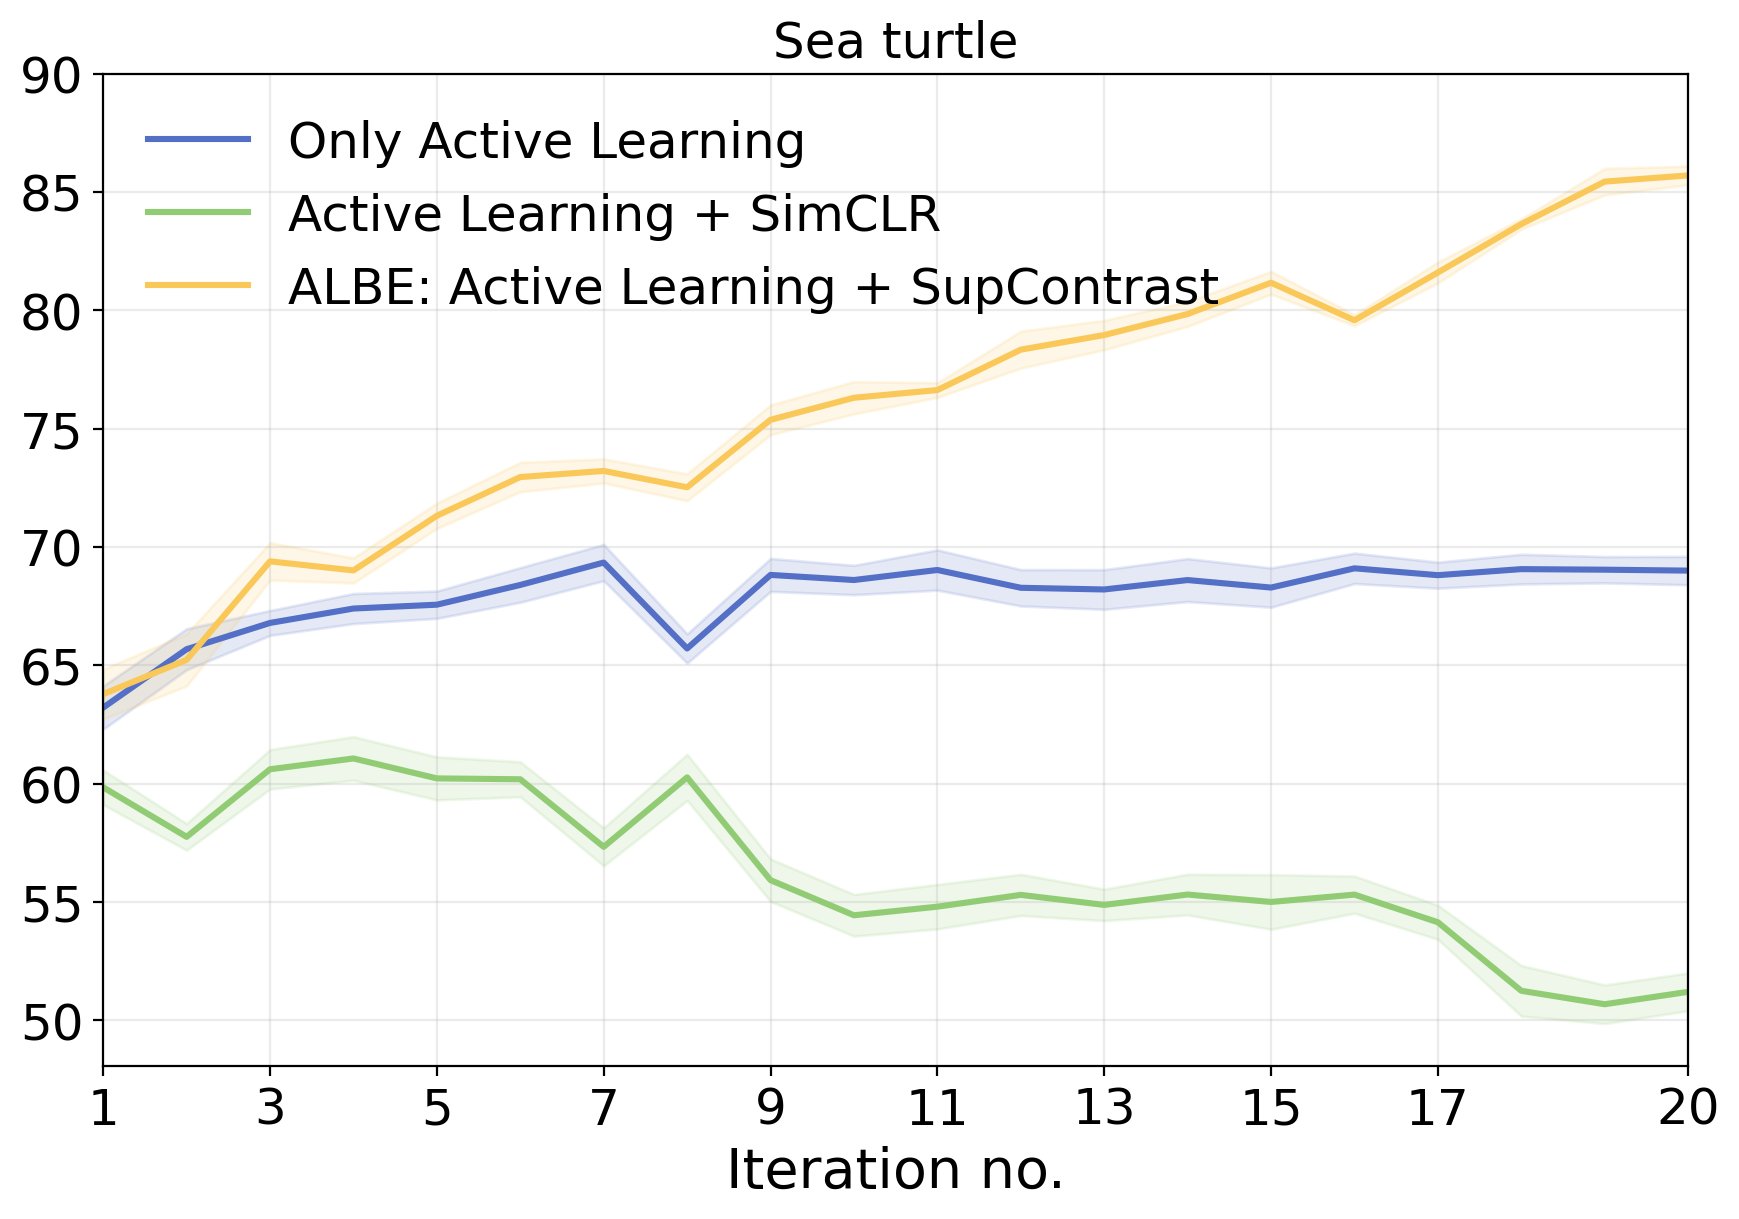

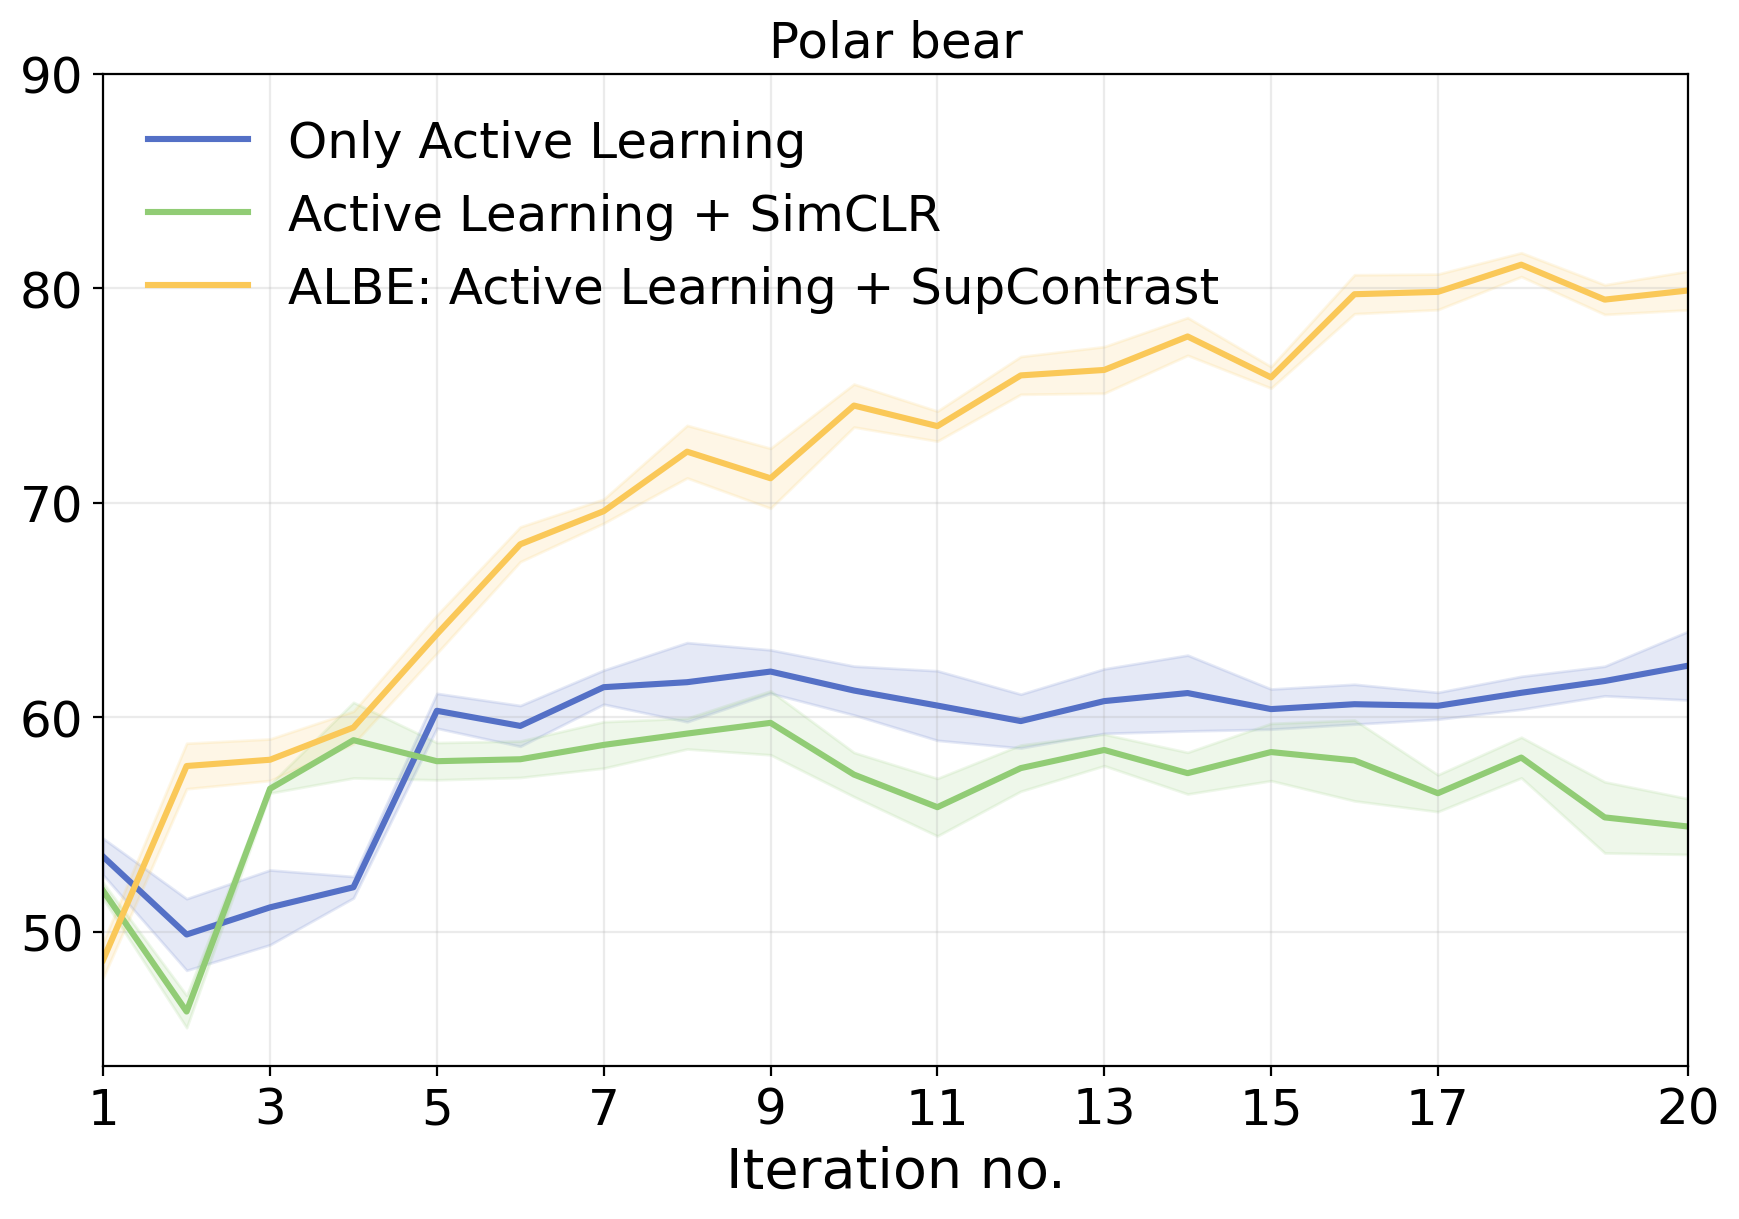

In [7]:
# -*- coding: utf-8 -*-
"""
先通过cal_Silhouette_KNN.py获得txt文件
Figure 3 — Panel E (Macro-F1 only)
Reads /mnt/data/acc_*.txt (JSON or JSONL), groups by (species, method),
and plots Macro-F1 (mean ± std) vs. iteration. One figure per species.

File schema (each line/object):
{
  "iteration": int,
  "labeled_n": int,
  "unlabeled_n": int,
  "knn_f1_mean": float,   # Macro-F1 in [0,1]
  "knn_f1_std":  float    # std in [0,1]
  ... (other fields allowed)
}
"""

import os, json, re
import numpy as np
import matplotlib.pyplot as plt

# -------------------- helpers --------------------
def read_json_txt(path):
    """Read JSON (list/dict) or JSONL; return list[dict]."""
    with open(path, "r", encoding="utf-8") as f:
        txt = f.read().strip()
    if not txt:
        return []
    try:
        obj = json.loads(txt)
        if isinstance(obj, dict):
            return [obj]
        if isinstance(obj, list):
            return obj
    except json.JSONDecodeError:
        pass
    rows = []
    for line in txt.splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except Exception:
            # silently skip unparsable lines
            pass
    return rows

def species_from_filename(fname: str) -> str:
    lf = fname.lower()
    if "umineko" in lf:
        return "Black-tailed gull"
    if "omizunagidori" in lf:
        return "Streaked shearwater"
    if "turtle" in lf:
        return "Sea turtle"
    if "bear" in lf:
        return "Polar bear"
    return "Unknown"

def method_from_filename(fname: str) -> str:
    lf = fname.lower()
    if "albe" in lf:
        return "ALBE: Active Learning + SupContrast"
    if "simclr" in lf:
        return "Active Learning + SimCLR"
    if "random" in lf:
        return "Only Active Learning"
    return "Unknown"



# -------------------- load --------------------
# root = "/mnt/data"
# files = [f for f in os.listdir(root) if f.startswith("acc_") and f.endswith(".txt")]

root_path = r'D:\code\DeepView\deepview\calculate_results\pape_results'

filenames = ['acc_gyr_dpt_turtle_random.txt', 'acc_gyr_dpt_turtle_albe.txt', 'acc_gyr_dpt_turtle_simclr.txt',
             'acc_omizunagidori_simclr.txt',
             'acc_omizunagidori_random.txt', 'acc_omizunagidori_albe.txt', 
             'acc_umineko_simclr.txt',
             'acc_umineko_random.txt', 'acc_umineko_albe.txt', 
             'acc_bear_random.txt', 'acc_bear_simclr.txt', 'acc_bear_albe.txt']

files = [os.path.join(root_path, fn) for fn in filenames]

by_species = {}
for fn in files:
    # path = os.path.join(root, fn)
    rows = read_json_txt(fn)
    if not rows:
        print(f"[WARN] empty or unreadable: {fn}")
        continue
    rows = sorted(rows, key=lambda r: r.get("iteration", 0))
    sp = species_from_filename(fn)
    md = method_from_filename(fn)
    by_species.setdefault(sp, {}).setdefault(md, []).append(rows)

# desired plotting order (also affects default color order)
method_order = [
    "Only Active Learning",
    "Active Learning + SimCLR",
    "ALBE: Active Learning + SupContrast",
]

species_order = [
    "Black-tailed gull",
    "Streaked shearwater",
    "Sea turtle",
    "Polar bear",
]


# 方法配色（必须：黄=ALBE，绿=Active+SimCLR，蓝=Only Active）
method_colors = {
    "Only Active Learning":                "#5470C6",  # 蓝
    "Active Learning + SimCLR":            "#91CC75",  # 绿
    "ALBE: Active Learning + SupContrast": "#FAC858",  # 黄
    # 兼容简写
    "Active": "#5470C6",
    "Active + SimCLR": "#91CC75",
    "ALBE": "#FAC858",
}

# def pick_color(name: str) -> str:
#     """根据方法名匹配颜色；不匹配则用灰色。"""
#     lname = name.lower()
#     for k, v in method_colors.items():
#         if k.lower() in lname:
#             return v
#     return "#666666"
# -------------------- plot per species --------------------
for sp in species_order:
    methods = by_species.get(sp, {})
    if not methods:
        print(f"[MISSING] No files for species: {sp}")
        continue

    plt.figure(figsize=(8.8, 6.2), dpi=200)

    # OPTIONAL: exact colors to match your sample (uncomment to enable)
    # color_map = {
    #     "Only Active Learning":               "#1f77b4",  # blue
    #     "Active Learning + SimCLR":           "#2ca02c",  # green
    #     "ALBE: Active Learning + SupContrast":"#ff7f0e",  # orange
    # }

    for md in method_order:
        if md not in methods:
            print(f"[MISSING] {sp} × {md}")
            continue

        # merge all seed files if multiple exist: here we simply concatenate then sort
        all_rows = []
        for seq in methods[md]:
            all_rows.extend(seq)
        all_rows.sort(key=lambda r: r.get("iteration", 0))

        its   = [r.get("iteration") for r in all_rows if "knn_f1_mean" in r]
        f1m   = [r["knn_f1_mean"] for r in all_rows if "knn_f1_mean" in r]
        f1s   = [r.get("knn_f1_std", 0.0) for r in all_rows if "knn_f1_mean" in r]

        if not its:
            print(f"[WARN] no Macro-F1 in {sp} × {md}")
            continue

        # convert to percentage
        f1m = np.array(f1m, dtype=float) * 100.0
        f1s = np.array(f1s, dtype=float) * 100.0

        # Plot mean curve
        # kwargs = {"color": color_map.get(md)}  # enable only if you uncomment color_map above
        kwargs = {}
        plt.plot(its, f1m, linewidth=2.2, label=md, color=method_colors[md], **kwargs)

        # Shaded ±1 SD band (if std provided)
        if np.isfinite(f1s).all() and (f1s > 0).any():
            plt.fill_between(its, f1m - f1s, f1m + f1s, alpha=0.15, color=method_colors[md], **kwargs)

    # Axes & cosmetics (match the sample style)
    plt.xlabel("Iteration no.", fontsize=20)
    # plt.ylabel("Weighted Macro F1 Score (%)", fontsize=20)

    # Set x-limits and ticks similar to sample (1..20)
    if methods:
        all_iters = []
        for md in method_order:
            if md in methods:
                all_iters.extend([r.get("iteration") for seq in methods[md] for r in seq if "knn_f1_mean" in r])
        if all_iters:
            xmin, xmax = min(all_iters), max(all_iters)
            plt.xlim(xmin, xmax)
            plt.xticks(np.linspace(xmin, xmax, num=min(10, xmax - xmin + 1), dtype=int))

    # Y range with small margins
    ymin, ymax = plt.ylim()
    plt.ylim(min(50, ymin), min(100, max(90, ymax)))  # keep within 50..100 for readability

    plt.grid(True, alpha=0.25)
    
    ax = plt.gca()
    ax.tick_params(axis="both", labelsize=18)
    
    
    # 图例字体
    leg = ax.legend(frameon=False, prop={"size": 18})
    # plt.legend(frameon=False)
    plt.title(sp, fontsize=18)
    plt.tight_layout()
    plt.show()
